In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

ROOT = Path(".")
RAW_DATA_DIR = ROOT / "raw_data"

In [13]:
sns.set_theme(style="whitegrid")

df = pd.read_csv(RAW_DATA_DIR / 'University Student Mental Health.csv')
display(df.head())

,StartDate,EndDate,Duration (in seconds),Eligibility,Age,Ethnicity,Ethnicity_text,Sex,Gender,Year_credits,...,Post_PSS_1,Post_PSS_2,Post_PSS_3,Post_PSS_4,Post_PSS_5,Post_PSS_6,Post_PSS_7,Post_PSS_8,Post_PSS_9,Post_PSS_10
0,2020-09-22 13:57,2020-09-22 14:05,461.0,1.0,18.0,2.0,NaN,2.0,2.0,1.0,...,4.0,3.0,3.0,1.0,3.0,3.0,2.0,3.0,3.0,3.0
1,2020-09-22 14:16,2020-09-22 14:36,1215.0,1.0,18.0,1.0,NaN,2.0,2.0,1.0,...,5.0,4.0,3.0,4.0,2.0,2.0,3.0,4.0,3.0,2.0
2,2020-09-22 14:59,2020-09-22 15:07,526.0,1.0,18.0,2.0,NaN,2.0,2.0,1.0,...,2.0,3.0,4.0,3.0,4.0,4.0,2.0,3.0,4.0,4.0
3,2020-09-22 16:07,2020-09-22 16:15,516.0,1.0,19.0,1.0,NaN,2.0,2.0,1.0,...,4.0,4.0,5.0,4.0,2.0,4.0,3.0,3.0,4.0,3.0
4,2020-09-22 17:15,2020-09-22 18:01,2751.0,1.0,18.0,1.0,NaN,2.0,2.0,1.0,...,2.0,1.0,5.0,4.0,3.0,3.0,4.0,3.0,5.0,3.0


Top 20 Columns with the Most Missing Data (%):
Ethnicity_text    94.575045
Diagnosis_text    79.324895
Catch_question    54.912598
DASS_6            28.149488
DERS_16           28.149488
DASS_1            28.149488
DASS_2            28.149488
DASS_3            28.149488
DASS_4            28.149488
DASS_5            28.149488
StartDate         28.149488
DASS_7            28.149488
DERS_15           28.149488
DASS_9            28.149488
DASS_10           28.149488
DASS_11           28.149488
DASS_12           28.149488
DASS_13           28.149488
DASS_8            28.149488
DERS_14           28.149488
dtype: float64


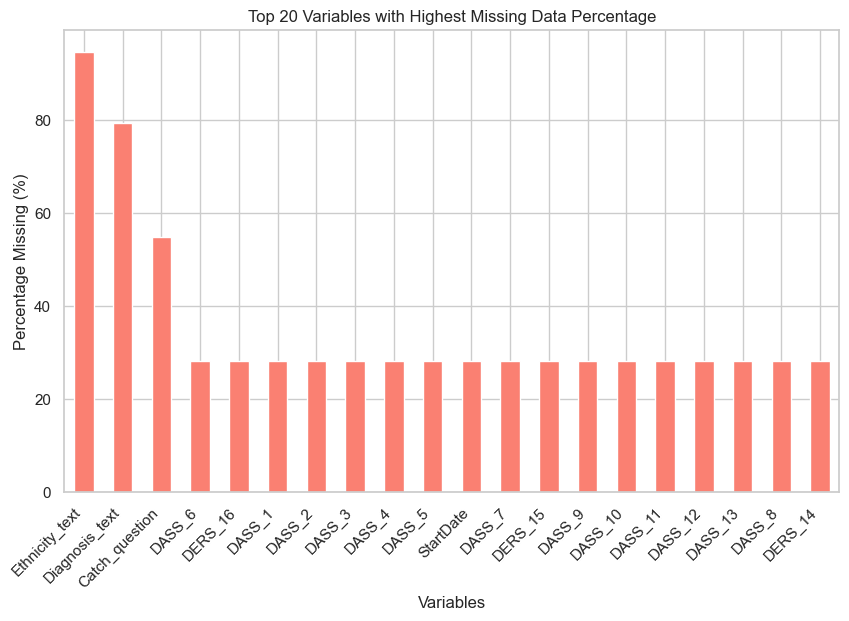

In [14]:
missing_data = df.isnull().sum() / len(df) * 100

missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

print("Top 20 Columns with the Most Missing Data (%):")
print(missing_data.head(20))

plt.figure(figsize=(10, 6))
missing_data.head(20).plot(kind='bar', color='salmon')
plt.title('Top 20 Variables with Highest Missing Data Percentage')
plt.ylabel('Percentage Missing (%)')
plt.xlabel('Variables')
plt.xticks(rotation=45, ha='right')
plt.show()

In [15]:
program_map = {
    1.0: 'Business',
    2.0: 'Education',
    3.0: 'Engineering',
    4.0: 'Fine Arts',
    5.0: 'Human and social development',
    6.0: 'Humanities',
    7.0: 'Sciences',
    8.0: 'Social Sciences'
}

df['Program_Text'] = df['Program'].map(program_map)


for col in ['Pre_GAD_1', 'Pre_GAD_2', 'Post_GAD_1', 'Post_GAD_2']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['Pre_Anxiety_Score'] = (df['Pre_GAD_1'] - 1) + (df['Pre_GAD_2'] - 1)
df['Post_Anxiety_Score'] = (df['Post_GAD_1'] - 1) + (df['Post_GAD_2'] - 1)

print("Program data mapped and anxiety scores calculated successfully!")

Program data mapped and anxiety scores calculated successfully!


/var/folders/ll/0h74wj397gz169ghhnjyvj640000gn/T/ipykernel_2994/4057589101.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Program_Text'] = df['Program'].map(program_map)
/var/folders/ll/0h74wj397gz169ghhnjyvj640000gn/T/ipykernel_2994/4057589101.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Pre_Anxiety_Score'] = df['Pre_GAD_1'] + df['Pre_GAD_2']
/var/folders/ll/0h74wj397gz169ghhnjyvj640000gn/T/ipykernel_2994/4057589101.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of c

/var/folders/ll/0h74wj397gz169ghhnjyvj640000gn/T/ipykernel_2994/2455514116.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/ll/0h74wj397gz169ghhnjyvj640000gn/T/ipykernel_2994/2455514116.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


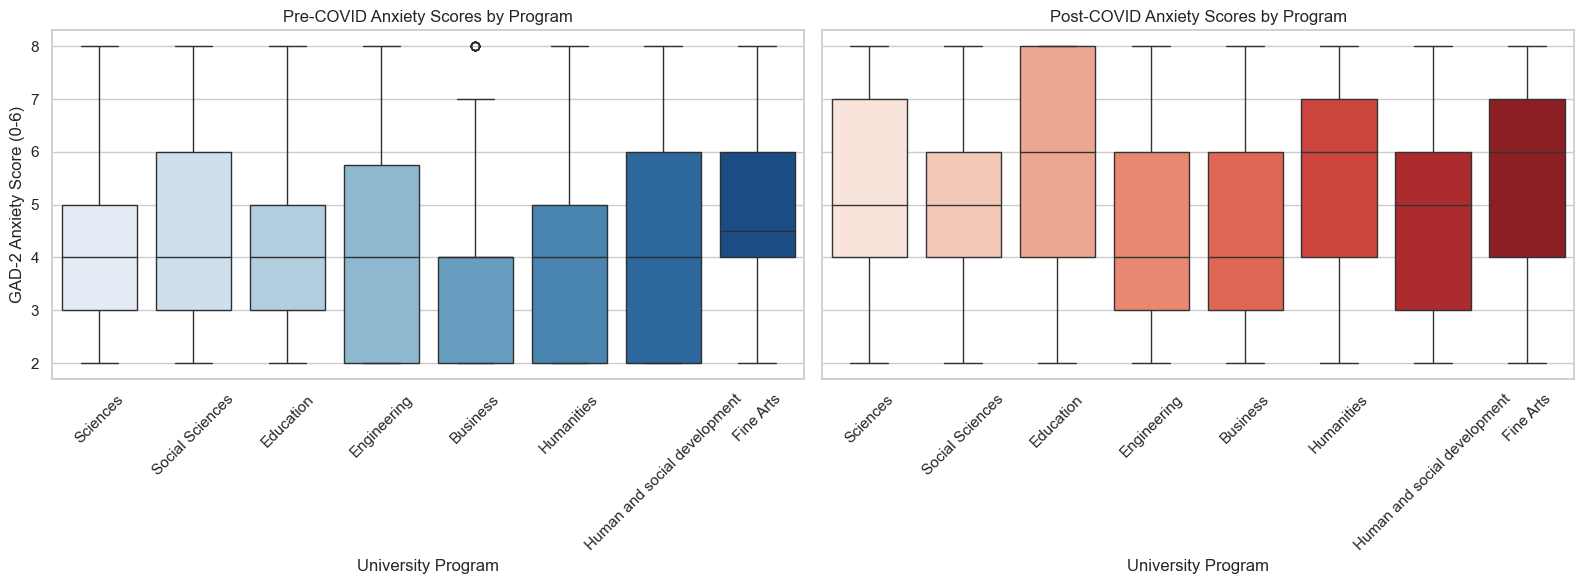

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

sns.boxplot(
    data=df, 
    x='Program_Text', 
    y='Pre_Anxiety_Score', 
    ax=axes[0], 
    palette='Blues'
)
axes[0].set_title('Pre-COVID Anxiety Scores by Program')
axes[0].set_xlabel('University Program')
axes[0].set_ylabel('GAD-2 Anxiety Score (0-6)')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(
    data=df, 
    x='Program_Text', 
    y='Post_Anxiety_Score', 
    ax=axes[1], 
    palette='Reds'
)
axes[1].set_title('Post-COVID Anxiety Scores by Program')
axes[1].set_xlabel('University Program')
axes[1].set_ylabel('') 
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

/var/folders/ll/0h74wj397gz169ghhnjyvj640000gn/T/ipykernel_2994/1684570267.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Pre_Depression_Score'] = df[pre_phq].sum(axis=1)
/var/folders/ll/0h74wj397gz169ghhnjyvj640000gn/T/ipykernel_2994/1684570267.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Post_Depression_Score'] = df[post_phq].sum(axis=1)
/var/folders/ll/0h74wj397gz169ghhnjyvj640000gn/T/ipykernel_2994/1684570267.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calli

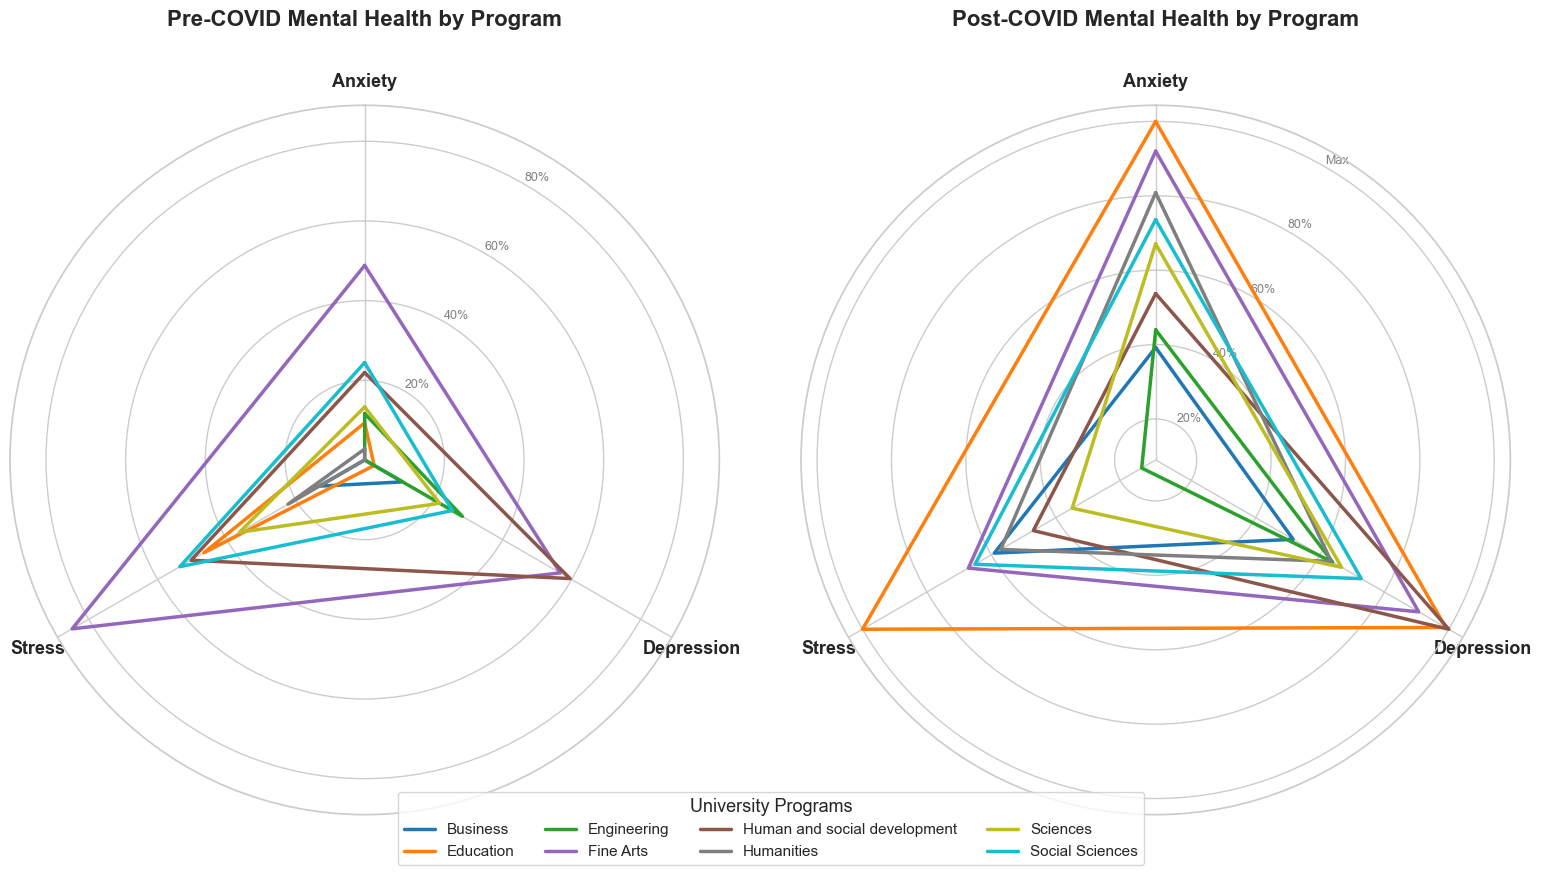

In [ ]:
pre_phq = ['Pre_PHQ_1', 'Pre_PHQ_2']
post_phq = ['Post_PHQ_1', 'Post_PHQ_2']
pre_pss = [f'Pre_PSS_{i}' for i in range(1, 11)]
post_pss = [f'Post_PSS_{i}' for i in range(1, 11)]

all_new_cols = pre_phq + post_phq + pre_pss + post_pss
for col in all_new_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[pre_phq] = df[pre_phq].clip(1, 4)
df[post_phq] = df[post_phq].clip(1, 4)

df[pre_pss] = df[pre_pss].clip(1, 5)
df[post_pss] = df[post_pss].clip(1, 5)

df['Pre_Depression_Score'] = (df[pre_phq] - 1).sum(axis=1)
df['Post_Depression_Score'] = (df[post_phq] - 1).sum(axis=1)
df['Pre_Stress_Score'] = (df[pre_pss] - 1).sum(axis=1)
df['Post_Stress_Score'] = (df[post_pss] - 1).sum(axis=1)

radar_data = df.groupby('Program_Text')[['Pre_Anxiety_Score', 'Post_Anxiety_Score', 
                                         'Pre_Depression_Score', 'Post_Depression_Score', 
                                         'Pre_Stress_Score', 'Post_Stress_Score']].mean().reset_index()
radar_data = radar_data.dropna()

categories = ['Anxiety', 'Depression', 'Stress']

max_scores = {'Anxiety': 6, 'Depression': 6, 'Stress': 40}
for m in categories:
    max_val = max_scores[m]
    radar_data[f'Pre_{m}_Norm'] = (radar_data[f'Pre_{m}_Score'] / max_val).clip(0, 1)
    radar_data[f'Post_{m}_Norm'] = (radar_data[f'Post_{m}_Score'] / max_val).clip(0, 1)

N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, axes = plt.subplots(1, 2, figsize=(16, 8), subplot_kw=dict(polar=True))
colors = plt.cm.tab10(np.linspace(0, 1, len(radar_data)))

for ax in axes:
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=13, weight='bold')
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['20%', '40%', '60%', '80%', 'Max'], color="grey", size=9)
    
    ax.set_rlabel_position(30)

axes[0].set_title('Pre-COVID Mental Health by Program', size=16, y=1.1, weight='bold')
axes[1].set_title('Post-COVID Mental Health by Program', size=16, y=1.1, weight='bold')

lines = [] 
labels = []

for i, row in radar_data.iterrows():
    values_pre = [row[f'Pre_{m}_Norm'] for m in categories]
    values_pre += values_pre[:1]
    line, = axes[0].plot(angles, values_pre, linewidth=2.5, linestyle='solid', color=colors[i])
    
    values_post = [row[f'Post_{m}_Norm'] for m in categories]
    values_post += values_post[:1]
    axes[1].plot(angles, values_post, linewidth=2.5, linestyle='solid', color=colors[i])
    
    lines.append(line)
    labels.append(row['Program_Text'])

fig.legend(lines, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.05), title="University Programs", title_fontsize='13', fontsize='11')

plt.tight_layout()
plt.show()